In [3]:
mkdir -p ~/.kaggle && echo KGAT_10395a4b7f7478ae77b994a3087a55db > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats
Path to dataset files: /kaggle/input/dogsvscats


In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt

In [6]:
#generators used for large dataset divides data into batches
# Load the training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.


In [7]:
# Load the validation dataset using generator by keras
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/dogsvscats/test',
    labels='inferred',
    label_mode='int',# makes 0 and 1 to cat and dogs
    batch_size=32,
    image_size=(256, 256)#makes everyone same size
)

Found 5000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [8]:
#Stored in numpy array
#Normalize from 0-255 to 0 to 1
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [23]:
from keras.layers import GlobalAveragePooling2D

In [29]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), padding='valid', activation='relu', input_shape=(256, 256, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(64, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(Conv2D(128, kernel_size=(3, 3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid'))
model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,977 (464.75 KB)

 Trainable params: 118,529 (463.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [32]:
from keras.callbacks import EarlyStopping

In [33]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,           # wait 3 epochs
    restore_best_weights=True,
    verbose=1
)

In [34]:
history=model.fit(train_ds,epochs=10, validation_data=validation_ds,callbacks=[early_stopping])

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 90ms/step - accuracy: 0.6229 - loss: 0.6439 - val_accuracy: 0.5352 - val_loss: 0.8746
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.6917 - loss: 0.5826 - val_accuracy: 0.7012 - val_loss: 0.5848
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.7276 - loss: 0.5465 - val_accuracy: 0.6990 - val_loss: 0.5836
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7483 - loss: 0.5196 - val_accuracy: 0.7274 - val_loss: 0.5612
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7683 - loss: 0.4876 - val_accuracy: 0.6232 - val_loss: 0.6274
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7912 - loss: 0.4515 - val_accuracy: 0.7384 - val_loss: 0.5798
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 87ms/step - accuracy: 0.8185 - loss: 0.4078 - val_accuracy: 0.7942 - val_loss: 0.4427
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.8394 - loss: 0.3686 - 

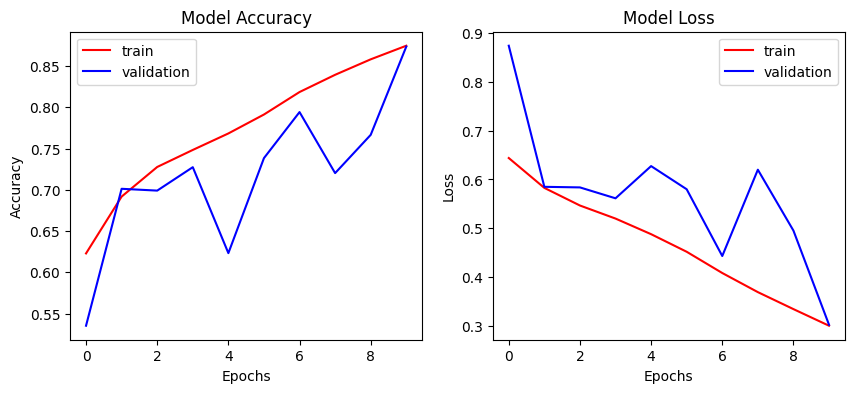

In [35]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [36]:
model.save('model.h5')

In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 799.2 kB/s eta 0:00:50
    --------------------------------------- 0.8/40.2 MB 882.6 kB/s eta 0:00:45
   - -------------------------------------- 1.0/40.2 MB 931.8 kB/s eta 0:00:43
   - -------------------------------------- 1.3/40.2 MB 1.0 MB/s eta 0:00:38
   - -------------------------------------- 1.8/40.2 MB 1.2 MB/s eta 0:00:32
   -- ------------------------------------- 2.1/40.2 MB 1.3 MB/s eta 0:00:30
   -- ------------------------------------- 2.6/40.2 MB 1.4 MB/s eta 0:00:27
   --- ------------------------------------ 3.4/40.2 MB 1.6 MB/s eta 0:00:24
   --- ------------------------------------ 3.9/40.2 MB 1.7 MB/s eta 0:00:22
   ---- -------------


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\RAJEEV YADAV\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip
